# Improving embeddings for low-count cells with JointEmbeddingSCVI

It is recommended to filter scRNA-seq data to remove cells with few UMI counts: 
their standard SCVI representations carry little biological signal, so they are usually discarded during quality control. Unfortunately, if there are issues with the sample
source for the cells, you might obtain a dataset with a large fraction of low-UMI cells,
meaning that you would end up discarding a large amount of precious data.

To attempt to recover embneddings for some typically lost cells `JointEmbeddingSCVI` adds a self-supervised, joint-embedding objective: during training each cell is
also *binomially thinned* to a lower depth, both views are encoded, and a cross-correlation loss (Barlow Twins / VICReg style) ties the thinned embedding to the original.

This method is not _magic_, using clean high quality data will always be a better
option if possible. It will not work well if _all_ cells have extremely low UMI: there need to be high-UMI cells to downsample and serve as examples. It also works better
when there is a large number of cells to train on (so there are many examples for
the paired training).

In this tutorial we use subsampling to illustrate how to use the `JointEmbeddingSCVI` 
model to improve embeddings for low-UMI cells.

Reference: Svensson, *Improving SCVI for low-count cells through self-supervised augmentation*, bioRxiv 2026.
[doi:10.64898/2026.02.11.705441](https://www.biorxiv.org/content/10.64898/2026.02.11.705441v1).

In [1]:
!pip install --quiet scvi-colab
from scvi_colab import install

install()


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi_colab/_core.py:42: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import ContextualVersionConflict
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi_colab/_core.py:47: UserWarning: 
                Not currently in Google Colab environment.

                Please run with `run_outside_colab=True` to override.

                Returning with no further action.
                
  warn(


## Setup

The `PYTORCH_ENABLE_MPS_FALLBACK` flag lets the binomial-thinning op fall back to CPU when training on
Apple-silicon (MPS); it is harmless on other platforms.

In [2]:
import os
import tempfile

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import scanpy as sc
import scipy.sparse as sp
import scvi

scvi.settings.seed = 0
print("scvi-tools version:", scvi.__version__)
save_dir = tempfile.TemporaryDirectory()

Seed set to 0


scvi-tools version: 1.4.3


## Load the data

We use the human PBMC dataset GSE310923 (51,277 cells, young/old donors), downloaded from
[Zenodo](https://zenodo.org/records/20902782) (about 400 MB). Raw integer counts are in `adata.X`, and
`adata.obs["cell_type"]` holds 18 annotated cell types we will use for coloring. We 
don't subset to highly variable genes — the model is trained on all genes.

In [3]:
adata_path = os.path.join(save_dir.name, "GSE310923_PBMC_clean.h5ad")

adata = sc.read(
    adata_path,
    backup_url="https://exampledata.scverse.org/scvi-tools/GSE310923_PBMC_clean.h5ad",
)

adata.layers["counts"] = adata.X.copy()
print(adata)
print("Observed UMI range:", int(adata.X.sum(1).min()), "-", int(adata.X.sum(1).max()))

  0%|          | 0.00/288M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 51277 × 32338
    obs: 'cell_type', 'Age', 'sample_id'
    layers: 'counts'
Observed UMI range: 1591 - 180918


In [4]:
adata.obs.head()

,cell_type,Age,sample_id
s13_AAACCCAAGTACGTCT-1,CD8 Tm,old,s13
s13_AAACCCACACCGAATT-1,nonclassical monocyte,old,s13
s13_AAACCCACATCCTTCG-1,B follicular,old,s13
s13_AAACCCAGTATCGGTT-1,nonclassical monocyte,old,s13
s13_AAACCCAGTCACATTG-1,inflammatory monocyte,old,s13


## Emulate raw data with low UMIs

This published dataset has already been QC-filtered: its lowest-count cell still has ~1,600 UMIs, so the low-UMI cells are gone. To demonstrate the low-depth scenario we recreate them by binomial thinning. Since we need to have some examples of high-depth
cells for training, we randomize the subsampling.

Typical QC threshold for UMI counts are on the order of 1,000 UMIs. Here we apply a  very permissive QC filter of 20 UMIs.

In [5]:
def thin_to_depth(counts, target_depth, rng):
    """Binomially thin each cell toward a per-cell ``target_depth``.

    Cells whose observed depth is already at or below their target are left
    unchanged (we can only remove counts, not add them), so the high-count cells
    are preserved. Each retained count y_g becomes Binomial(y_g, target/observed).
    """
    counts = sp.csr_matrix(counts).astype(np.int64)
    obs_depth = np.asarray(counts.sum(axis=1)).ravel().astype(float)
    p = np.clip(target_depth / np.maximum(obs_depth, 1.0), 0.0, 1.0)
    thinned = counts.copy()
    row_p = np.repeat(p, np.diff(counts.indptr))
    thinned.data = rng.binomial(counts.data, row_p).astype(np.int64)
    thinned.eliminate_zeros()
    return thinned

In [6]:
rng = np.random.default_rng(0)

# Broaden the depth distribution with a smooth, per-cell thinning factor:
# factor ~ 10**Normal(mu, sigma), capped at 1 (we can only remove counts). Cells that
# draw a factor near 1 keep their depth as high-count anchors; the rest spread down
# into a low-count tail.
MU, SIGMA = -1.0, 1.0
MIN_UMI = 20  # very permissive floor: drop only essentially empty droplets

obs_depth = np.asarray(adata.layers["counts"].sum(axis=1)).ravel().astype(float)
factor = np.minimum(1.0, 10 ** rng.normal(MU, SIGMA, size=adata.n_obs))
counts = thin_to_depth(adata.layers["counts"], obs_depth * factor, rng)

adata.X = counts
adata.layers["counts"] = counts
adata.obs["total_umi"] = np.asarray(counts.sum(axis=1)).ravel()

# Even permissive QC drops near-empty droplets: they carry no usable signal for any
# model, and a 0-count cell has no defined log-depth.
adata = adata[adata.obs["total_umi"] >= MIN_UMI].copy()
adata.obs["log10_umi"] = np.log10(adata.obs["total_umi"])

print(f"Cells retained (>= {MIN_UMI} UMIs): {adata.n_obs:,}")
print(
    "UMI percentiles:",
    {q: int(np.percentile(adata.obs["total_umi"], q)) for q in (1, 10, 50, 90, 99)},
)
print("Fraction below 1,000 UMIs:", round((adata.obs["total_umi"] < 1000).mean(), 3))

Cells retained (>= 20 UMIs): 48,074
UMI percentiles: {1: 23, 10: 68, 50: 899, 90: 7602, 99: 21432}
Fraction below 1,000 UMIs: 0.517


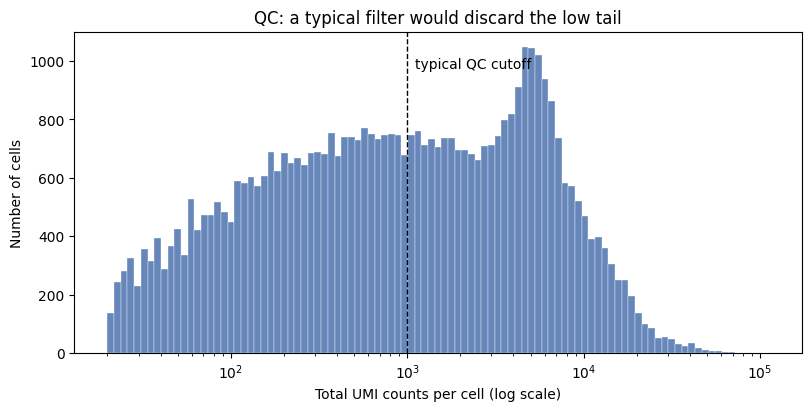

In [7]:
import matplotlib.pyplot as plt

typical_cutoff = 1000

umi = adata.obs["total_umi"].to_numpy()
umi_pos = umi[umi > 0]
bins = np.logspace(np.log10(umi_pos.min()), np.log10(umi.max()), 100)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.hist(umi_pos, bins=bins, color="#4C72B0", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.axvline(typical_cutoff, linestyle="--", color="black", linewidth=1)
ax.text(typical_cutoff * 1.1, ax.get_ylim()[1] * 0.92, "typical QC cutoff", ha="left", va="top")
ax.set_xlabel("Total UMI counts per cell (log scale)")
ax.set_ylabel("Number of cells")
ax.set_title("QC: a typical filter would discard the low tail")
plt.show()

## Train a standard SCVI model

Our baseline, trained on the full dataset spanning all depths (low-count cells included). We follow the
manuscript's hyperparameters: 32 latent dimensions, a negative binomial likelihood, 25 epochs.
`accelerator="auto"` uses a GPU (CUDA or Apple-silicon MPS) when available and falls back to CPU.

In [8]:
N_LATENT = 32
MAX_EPOCHS = 25
BATCH_SIZE = 512
LR = 0.004  # Scaled to BATCH_SIZE

scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="sample_id")
scvi_model = scvi.model.SCVI(adata, n_latent=N_LATENT, gene_likelihood="nb")
scvi_model.train(
    accelerator="auto",
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    plan_kwargs={"lr": LR},
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/l

Training:   0%|          | 0/25 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


## Train a JointEmbeddingSCVI model

The interface is identical to `SCVI`; we just add the joint-embedding weight. `joint_embedding_weight` is the strength of the cross-correlation objective (CCO); the default `joint_embedding_weight = 100` is a good starting point. If results look like
cells are still collapsing to a single cluster due to low deapth, try increasing it to
1000. If it's too aggressive, try 10. Thinning target depths are sampled per cell down to `min_library_size` (default 10); tuning this parameter doesn't change much.

In [9]:
scvi.external.JointEmbeddingSCVI.setup_anndata(adata, layer="counts", batch_key="sample_id")
je_model = scvi.external.JointEmbeddingSCVI(
    adata,
    n_latent=N_LATENT,
    gene_likelihood="nb",
    joint_embedding_weight=100.0,
    use_joint_embedding=True,
)
print(je_model)
je_model.train(
    accelerator="auto",
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    plan_kwargs={"lr": LR},
)

JointEmbeddingSCVI model with the following parameters: 
n_hidden: 128, n_latent: 32, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal, joint_embedding_weight: 100.0, lambda_off_diag: 0.01, min_library_size: 10.0, 
reconstruction_weight: 1.0, variance_weight: 0.0, use_joint_embedding: True.
Training status: Not Trained
Model's adata is minified?: False

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training:   0%|          | 0/25 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


## Visualize each models embeddings with TSNE

To compare the results, we perform TSNE on the latent representations of either the standard SCVI model or the JointEmbeddingSCVI model.

In [10]:
# Embed a random sample of cells for a legible, fast t-SNE (the latent and the
# quantification below run on this sample).
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sample_idx = rng.choice(adata.n_obs, size=min(10000, adata.n_obs), replace=False)
sample_idx.sort()
sample = adata[sample_idx].copy()


def latent_tsne(model, data):
    """Embed `data` with `model` and compute an independent t-SNE on the latent space.

    t-SNE is initialized from a PCA computed with the full (LAPACK) SVD solver. The
    default randomized solver (used by ``sc.tl.tsne``) divides by zero on the
    near-degenerate latent that bias-point collapse produces — many cells sharing
    almost identical coordinates — which otherwise floods the output with warnings.
    """
    ann = data.copy()
    z = model.get_latent_representation(data)
    ann.obsm["X_latent"] = z
    pca_init = PCA(n_components=2, svd_solver="full").fit_transform(z)
    pca_init = pca_init / pca_init[:, 0].std() * 1e-4  # sklearn's internal PCA-init scaling
    ann.obsm["X_tsne"] = TSNE(
        n_components=2, init=pca_init, perplexity=30, random_state=0
    ).fit_transform(z)
    return ann


tsne_scvi = latent_tsne(scvi_model, sample)
tsne_je = latent_tsne(je_model, sample)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [11]:
import matplotlib.pyplot as plt

# The two trained models, plotted as parallel independent analyses.
MODELS = [("SCVI baseline", tsne_scvi), ("JointEmbedding (w=100)", tsne_je)]

# Shared categorical palette so cell-type colors match across every panel.
cell_types = sorted(sample.obs["cell_type"].astype(str).unique())
palette = {c: plt.get_cmap("tab20")(i % 20) for i, c in enumerate(cell_types)}


def paired_axes(figsize=(11, 4.5)):
    """Two side-by-side, square-ish t-SNE panels with chrome stripped away."""
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    return fig, axes

### Embeddings will still depend on UMI depth

Coloring by UMI depth shows collapse of low-UMI cells. However, with the standard SCVI model the UMI depth gradients are more dramatic. There is more depth mixing with the  `JointEmbeddingSCVI` model.

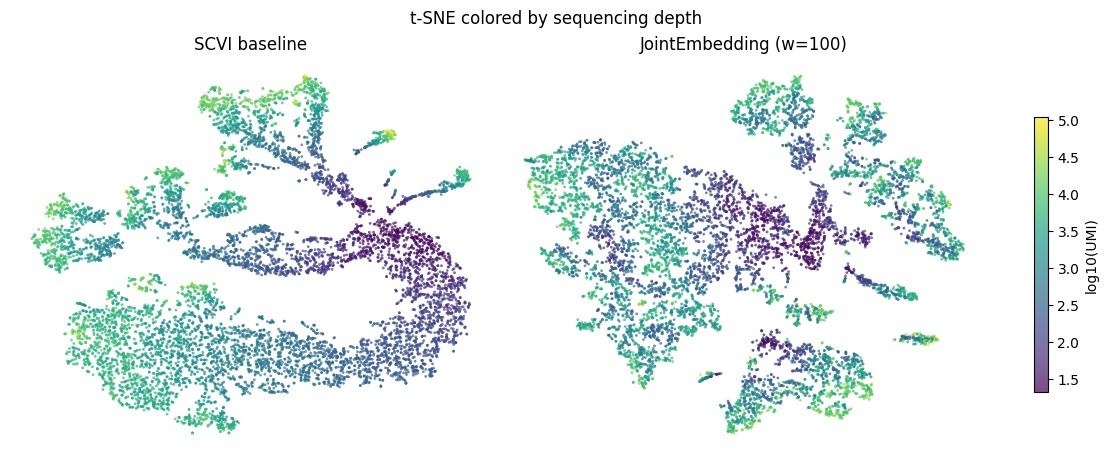

In [12]:
fig, axes = paired_axes((11, 4.5))
for ax, (name, ann) in zip(axes, MODELS, strict=True):
    depth = np.log10(ann.obs["total_umi"].to_numpy() + 1)
    sca = ax.scatter(
        ann.obsm["X_tsne"][:, 0],
        ann.obsm["X_tsne"][:, 1],
        c=depth,
        cmap="viridis",
        s=4,
        alpha=0.7,
        linewidths=0,
    )
    ax.set_title(name)
fig.colorbar(sca, ax=axes, label="log10(UMI)", shrink=0.7)
fig.suptitle("t-SNE colored by sequencing depth")
plt.show()

### Comparing cell type annotations

The cells in this dataset were assigned to cell types by the original authors. These
cell types labels were created using the original unsampled full-depth data. Cells
globally cluster by cell type annotation in both the models.

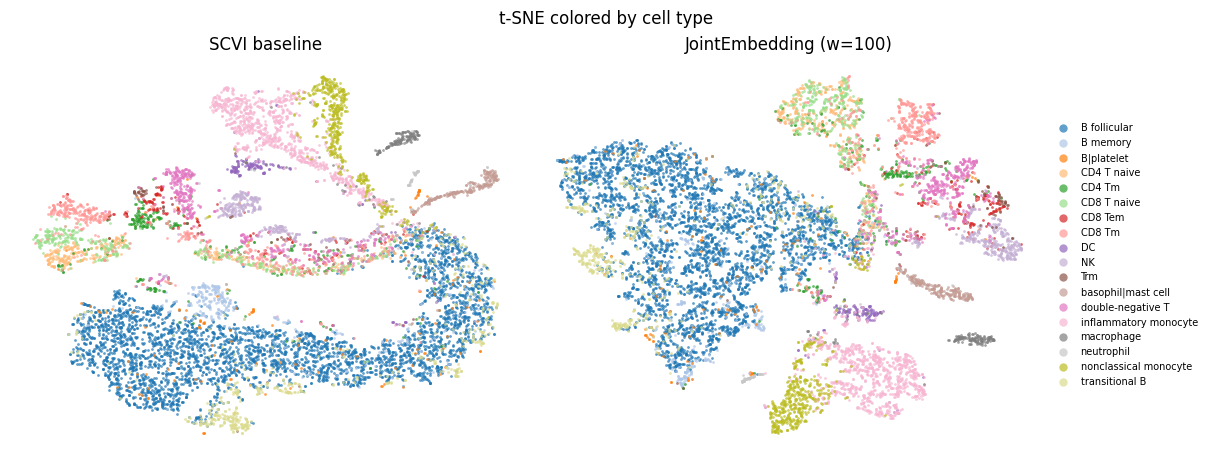

In [13]:
fig, axes = paired_axes((12, 4.5))
for ax, (name, ann) in zip(axes, MODELS, strict=True):
    ct = ann.obs["cell_type"].astype(str).to_numpy()
    for c in cell_types:
        m = ct == c
        ax.scatter(
            ann.obsm["X_tsne"][m, 0],
            ann.obsm["X_tsne"][m, 1],
            color=palette[c],
            s=4,
            alpha=0.7,
            linewidths=0,
            label=c,
        )
    ax.set_title(name)
axes[1].legend(
    markerscale=3, fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False
)
fig.suptitle("t-SNE colored by cell type")
plt.show()

### Cells that would have been QC filtered

An interesting part is comparing visualizations of embeddings for the cells that would
have been QC filtered due to having low UMI counts. We plot cells with > 1,000 UMIs
as grey dots in TSNE coordinates, and on top plot the cells with < 1,000 UMIs colored
by their annotated cell types.

When using the JointEmbedding model, more low-UMI cells mix with high-UMI cells.

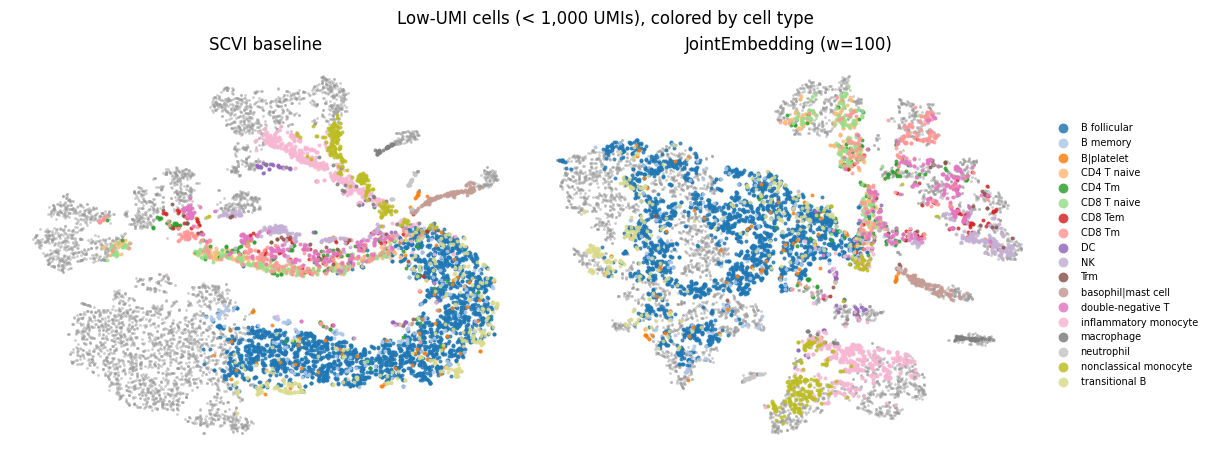

In [14]:
fig, axes = paired_axes((12, 4.5))
for ax, (name, ann) in zip(axes, MODELS, strict=True):
    xy = ann.obsm["X_tsne"]
    low = ann.obs["total_umi"].to_numpy() < typical_cutoff
    ct = ann.obs["cell_type"].astype(str).to_numpy()
    # Cells we would have kept anyway, as a visible grey background map.
    ax.scatter(xy[~low, 0], xy[~low, 1], color="#9a9a9a", s=4, alpha=0.5, linewidths=0)
    # The low-UMI cells a typical QC step would have removed, colored by cell type.
    for c in cell_types:
        m = low & (ct == c)
        if m.any():
            ax.scatter(
                xy[m, 0], xy[m, 1], color=palette[c], s=8, alpha=0.85, linewidths=0, label=c
            )
    ax.set_title(name)
axes[1].legend(
    markerscale=2.5, fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False
)
fig.suptitle(f"Low-UMI cells (< {typical_cutoff:,} UMIs), colored by cell type")
plt.show()

### Get Model(s) Latent Space and visualize models embeddings and integrations with UMAPS

In [15]:
latent = scvi_model.get_latent_representation()
adata.obsm["X_scVI"] = latent
je_latent = je_model.get_latent_representation()
adata.obsm["X_scVI_JE"] = je_latent

In [16]:
import rapids_singlecell as rsc

# run PCA then generate UMAP plots
sc.tl.pca(adata)
rsc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/rapids_singlecell/__init__.py:38: UserWarning: 
Multiple rapids_singlecell packages are installed: rapids-singlecell, rapids-singlecell-cu13
Please uninstall all versions and reinstall only one:
  pip uninstall rapids-singlecell rapids-singlecell-cu13

  _detect_duplicate_installation()


In [17]:
# use scVI latent space for UMAP generation
rsc.pp.neighbors(adata, use_rep="X_scVI")
rsc.tl.umap(adata, min_dist=0.3)

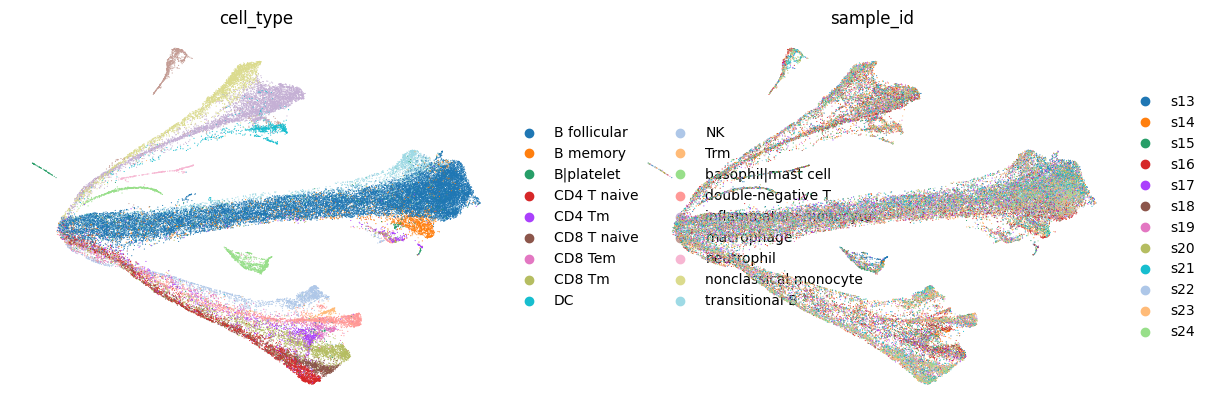

In [18]:
sc.pl.umap(
    adata,
    color=["cell_type", "sample_id"],
    frameon=False,
)

In [19]:
# use JE scVI latent space for UMAP generation
rsc.pp.neighbors(adata, use_rep="X_scVI_JE")
rsc.tl.umap(adata, min_dist=0.3)

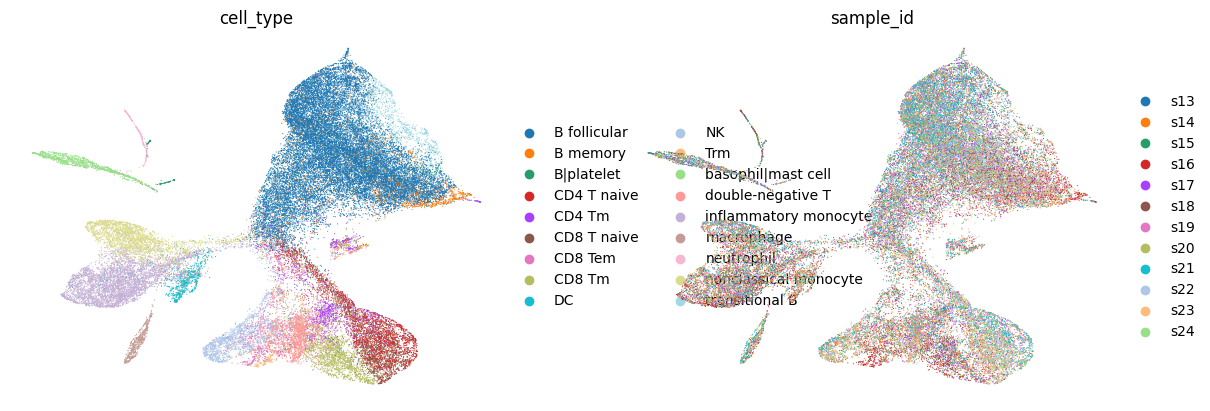

In [20]:
sc.pl.umap(
    adata,
    color=["cell_type", "sample_id"],
    frameon=False,
)

## Quantifying cell type mixing 

The TSNE visualization indicates that low-UMI cells intermix with high-UMI cells
supposedly of the same cell type.

We can quantify this, but doing a label-transfer style analysis from high-UMI cells
to low-UMI cells. Then we can compare transferred labels with true labels.

We fit a k-nearest-neighbor classifier on the full-depth cells' cell-type labels in each model's latent space, then predict the type of every low-UMI cell.

We report two numbers. **Overall accuracy** is the fraction of all low-UMI cells recovered — but this dataset is dominated by B follicular cells (~42%), so a model that simply pulls everything toward the largest cluster can score well on it. **Balanced accuracy** averages the recovery rate over the 18 cell types equally, so it reflects whether *every* cell type stays recoverable — which is what we actually care about when keeping low-count cells.

In [21]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.neighbors import KNeighborsClassifier

umi = sample.obs["total_umi"].to_numpy()
y = sample.obs["cell_type"].astype(str).to_numpy()
z_scvi = tsne_scvi.obsm["X_latent"]
z_je = tsne_je.obsm["X_latent"]

# Low-UMI ("would be filtered") vs full-depth cells, finite latent in both models.
finite = np.isfinite(z_scvi).all(axis=1) & np.isfinite(z_je).all(axis=1)
high = (umi >= typical_cutoff) & finite
low = (umi < typical_cutoff) & finite
y_low = y[low]


def transfer(z, k=15):
    """Predict low-UMI cell types from a kNN classifier fit on the full-depth cells."""
    clf = KNeighborsClassifier(n_neighbors=k).fit(z[high], y[high])
    return clf.predict(z[low])


pred_scvi = transfer(z_scvi)
pred_je = transfer(z_je)

# Overall accuracy is dominated by B follicular (~42% of cells); balanced accuracy
# averages over the 18 cell types equally, so it reflects whether *all* types survive.
o_scvi, b_scvi = accuracy_score(y_low, pred_scvi), balanced_accuracy_score(y_low, pred_scvi)
o_je, b_je = accuracy_score(y_low, pred_je), balanced_accuracy_score(y_low, pred_je)
print(f"Low-UMI cells (< {typical_cutoff:,} UMIs): recovery of the correct cell type")
print("(label transfer from full-depth cells, 15-NN in the latent space)\n")
print(f"{'':25}{'overall':>9}{'balanced':>11}")
print(f"  SCVI baseline:         {o_scvi:>8.1%}{b_scvi:>11.1%}")
print(f"  JointEmbedding (w=100):{o_je:>8.1%}{b_je:>11.1%}")

Low-UMI cells (< 1,000 UMIs): recovery of the correct cell type
(label transfer from full-depth cells, 15-NN in the latent space)

                           overall   balanced
  SCVI baseline:            71.6%      43.0%
  JointEmbedding (w=100):   73.9%      50.5%


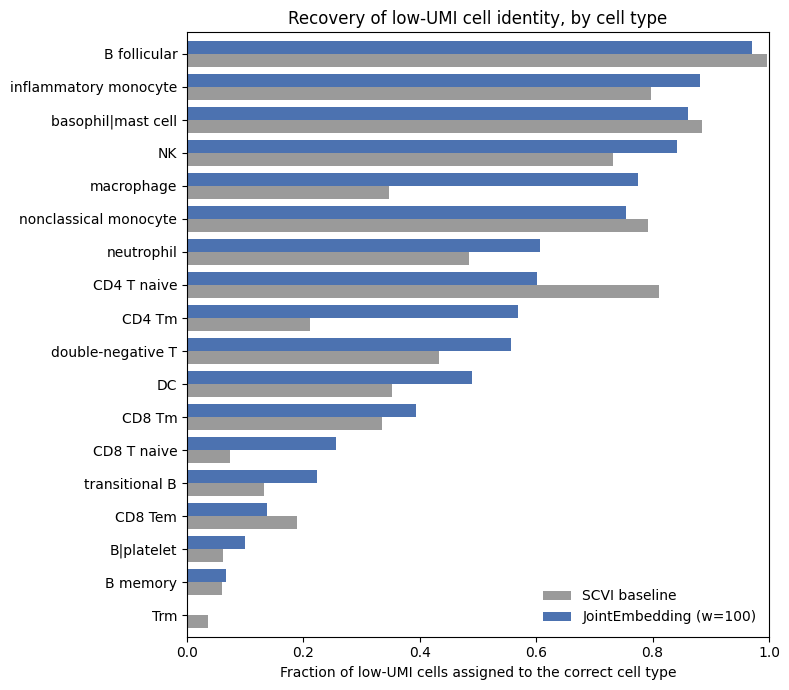

In [22]:
import pandas as pd

acc = (
    pd.DataFrame(
        {
            "cell_type": y_low,
            "SCVI baseline": pred_scvi == y_low,
            "JointEmbedding (w=100)": pred_je == y_low,
        }
    )
    .groupby("cell_type")[["SCVI baseline", "JointEmbedding (w=100)"]]
    .mean()
    .sort_values("JointEmbedding (w=100)")
)

ax = acc.plot.barh(figsize=(8, 7), color=["#9a9a9a", "#4C72B0"], width=0.8)
ax.set_xlabel("Fraction of low-UMI cells assigned to the correct cell type")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.set_title("Recovery of low-UMI cell identity, by cell type")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()